In [42]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import OneClassSVM
from imblearn.over_sampling import SMOTE
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import metrics
import lime
import lime.lime_tabular

In [43]:
df = pd.read_csv("ResearhData.csv")
print(df.shape)
df.head()

(2541, 13)


,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
0,NOSTRESS,-0.030326,-0.030742,0.000124,0.0,0.0,-0.810,0.3750,-1.121333,-0.036966,-0.5,-33.871843,-0.488629
1,NOSTRESS,-0.027412,-0.028501,0.003034,0.0,0.0,-1.320,0.3675,-0.771936,0.317007,-0.5,-33.871843,-0.488629
2,NOSTRESS,-0.027540,-0.028821,0.002604,0.0,0.0,-1.380,0.3625,-0.913694,0.263580,-0.5,-33.871843,-0.488629
3,NOSTRESS,-0.018734,-0.016492,0.004473,0.0,0.0,-2.285,0.4050,-0.272774,0.462842,-0.5,-33.871843,-0.488629
4,NOSTRESS,-0.012041,-0.014570,-0.005277,0.0,0.0,-2.715,0.4125,0.057561,0.002796,-0.5,-33.871843,-0.488629


In [44]:
df['Label'].unique()

array(['NOSTRESS', 'STRESS'], dtype=object)

## Data Description 

In [45]:
df.describe(include='all')

,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
count,2541,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000,2541.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,STRESS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.133460,0.134660,0.011387,0.226682,0.025125,9.303126,-0.317973,-0.110210,0.621465,-1.519776,-31.099023,-0.441252
std,NaN,0.310719,0.314339,0.039412,0.783278,0.105890,14.661003,0.599100,0.877497,1.110321,13.332870,32.091973,4.118833
min,NaN,-1.083348,-1.065445,-0.064407,-4.000000,-0.219829,-29.775000,-2.073750,-11.392412,-7.634984,-43.500000,-99.875000,-18.977173
25%,NaN,0.038008,0.039704,-0.000006,0.000000,0.000000,0.325000,-0.748750,-0.581779,0.045387,-10.000000,-52.300000,-2.154263
50%,NaN,0.085989,0.086309,0.001395,0.000000,0.000000,7.800000,-0.265000,-0.127017,0.250669,-0.500000,-33.871843,-0.488629
75%,NaN,0.157703,0.159619,0.007714,0.000000,0.000000,15.570000,0.067500,0.366051,0.993110,8.000000,-11.863636,1.978926


## Missingness

In [46]:
missing_counts = df.isnull().sum()

missing_counts = missing_counts[missing_counts > 2541/2]

missing_counts.sort_values(ascending=False)

Series([], dtype: int64)

## Low Variability

In [47]:
from sklearn.feature_selection import VarianceThreshold

df_num = df.select_dtypes(include=['number'])

# Set your variance threshold (e.g., 0.01 is a common starting point)
my_threshold = 0.01
selector = VarianceThreshold(threshold=my_threshold)
selector.fit(df_num)

# Get boolean mask of features that pass the threshold
mask = selector.get_support()

# Get list of all column names
all_features = df_num.columns

# Features that were removed (low variance)
low_variability_features = all_features[~mask]

# Show the names of low-variability columns
print("Low variability features (variance < {:.2f}):".format(my_threshold))
print(low_variability_features.tolist())

Low variability features (variance < 0.01):
['EDA_sd_delta']


In [48]:
for col in df.select_dtypes(include='object'):
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.95:
        print(f"{col} ({top_freq:.1%})")

In [49]:
df.dtypes

Label                 object
EDA_mean_delta       float64
EDA_median_delta     float64
EDA_sd_delta         float64
SCR_count_delta      float64
SCR_amp_delta        float64
HR_median_delta      float64
TEMP_median_delta    float64
ACC_vm_mean_delta    float64
ACC_vm_sd_delta      float64
HR_bangle_delta      float64
HR_conf_delta        float64
RMSSD_ECG_delta      float64
dtype: object

## Sampling 

In [50]:
pd.crosstab(index = df['Label'], columns = "count") 

col_0,count
Label,
NOSTRESS,1229
STRESS,1312


In [51]:
train = df.groupby("Label", group_keys=False).sample(frac=0.75, random_state=1234)
test = df.loc[df.index.difference(train.index)]
train.head()


,Label,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,HR_median_delta,TEMP_median_delta,ACC_vm_mean_delta,ACC_vm_sd_delta,HR_bangle_delta,HR_conf_delta,RMSSD_ECG_delta
2220,NOSTRESS,-0.091091,-0.091315,0.000187,-2.0,-0.043149,35.41,-0.2400,-0.450977,0.439211,-1.0,-62.000000,-4.964245
850,NOSTRESS,-0.031503,-0.033947,0.009839,0.5,0.041946,57.27,-1.3125,-0.497868,2.271804,10.0,-54.428571,-1.730073
427,NOSTRESS,0.194776,0.194680,-0.000229,0.0,0.000000,-28.80,1.3750,1.841169,0.090760,2.0,-44.550000,-0.622952
1162,NOSTRESS,0.340880,0.340912,0.000109,0.5,0.041793,11.06,-0.5550,-0.509152,0.090518,-19.0,-32.500000,-1.842775
849,NOSTRESS,-0.043683,-0.041794,0.002562,0.0,0.000000,56.23,-1.3225,0.495889,0.220549,8.5,-57.918182,-4.616893


In [52]:
pd.crosstab(index = train['Label'], columns = "count")


col_0,count
Label,
NOSTRESS,922
STRESS,984


In [53]:
pd.crosstab(index = test['Label'], columns = "count")


col_0,count
Label,
NOSTRESS,307
STRESS,328


In [54]:
# filling in number dtypes with median and flagging with missing 
train_o = train.copy()
num_cols = train_o.select_dtypes(include='number').columns

for col in num_cols:
    if train_o[col].isnull().any():
        # Create missing flag column
        train_o[f'{col}_was_missing'] = train_o[col].isnull().astype(int)

        # Impute with median
        median = train_o[col].median()
        train_o[col] = train_o[col].fillna(median)
print(train_o.columns)

Index(['Label', 'EDA_mean_delta', 'EDA_median_delta', 'EDA_sd_delta',
       'SCR_count_delta', 'SCR_amp_delta', 'HR_median_delta',
       'TEMP_median_delta', 'ACC_vm_mean_delta', 'ACC_vm_sd_delta',
       'HR_bangle_delta', 'HR_conf_delta', 'RMSSD_ECG_delta'],
      dtype='object')


In [55]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(train_o.dtypes)


Label                 object
EDA_mean_delta       float64
EDA_median_delta     float64
EDA_sd_delta         float64
SCR_count_delta      float64
SCR_amp_delta        float64
HR_median_delta      float64
TEMP_median_delta    float64
ACC_vm_mean_delta    float64
ACC_vm_sd_delta      float64
HR_bangle_delta      float64
HR_conf_delta        float64
RMSSD_ECG_delta      float64
dtype: object


In [56]:
# creating X and Y and creating dummies for categorical data 
predictors = train_o.drop(columns=['Label'])
predictors = pd.get_dummies(predictors, drop_first=True)
predictors = predictors.astype(float)

X = predictors

y = train_o['Label']



In [57]:
# using Pearson's square to sort data and determine association, 
# Use p-value of 0.002 depending on the data siize
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Separate categorical (dummy) vs. continuous features
continuous_features = [col for col in X.columns if X[col].nunique() > 2]

X_cont = X[continuous_features]




# Fit SelectKBest for Continous Variables
selector = SelectKBest(score_func=f_classif, k='all')  # 'all' keeps all features for scoring
selector.fit(X_cont, y)

# Create a DataFrame with feature names, F-scores, and p-values
scores_cont_df = pd.DataFrame({
    'Feature': X_cont.columns,
    'F_score': selector.scores_,
    'p_value': selector.pvalues_
})

# Filter for features with p-value < 0.002
selected_cont_features = scores_cont_df[scores_cont_df['p_value'] < 0.002]['Feature']

# Create a new DataFrame with only those selected columns
X_reduced = X[selected_cont_features.tolist()]

X_reduced.head()


,EDA_mean_delta,EDA_median_delta,EDA_sd_delta,SCR_count_delta,SCR_amp_delta,TEMP_median_delta,ACC_vm_sd_delta,HR_bangle_delta
2220,-0.091091,-0.091315,0.000187,-2.0,-0.043149,-0.2400,0.439211,-1.0
850,-0.031503,-0.033947,0.009839,0.5,0.041946,-1.3125,2.271804,10.0
427,0.194776,0.194680,-0.000229,0.0,0.000000,1.3750,0.090760,2.0
1162,0.340880,0.340912,0.000109,0.5,0.041793,-0.5550,0.090518,-19.0
849,-0.043683,-0.041794,0.002562,0.0,0.000000,-1.3225,0.220549,8.5


## Decision Tree 

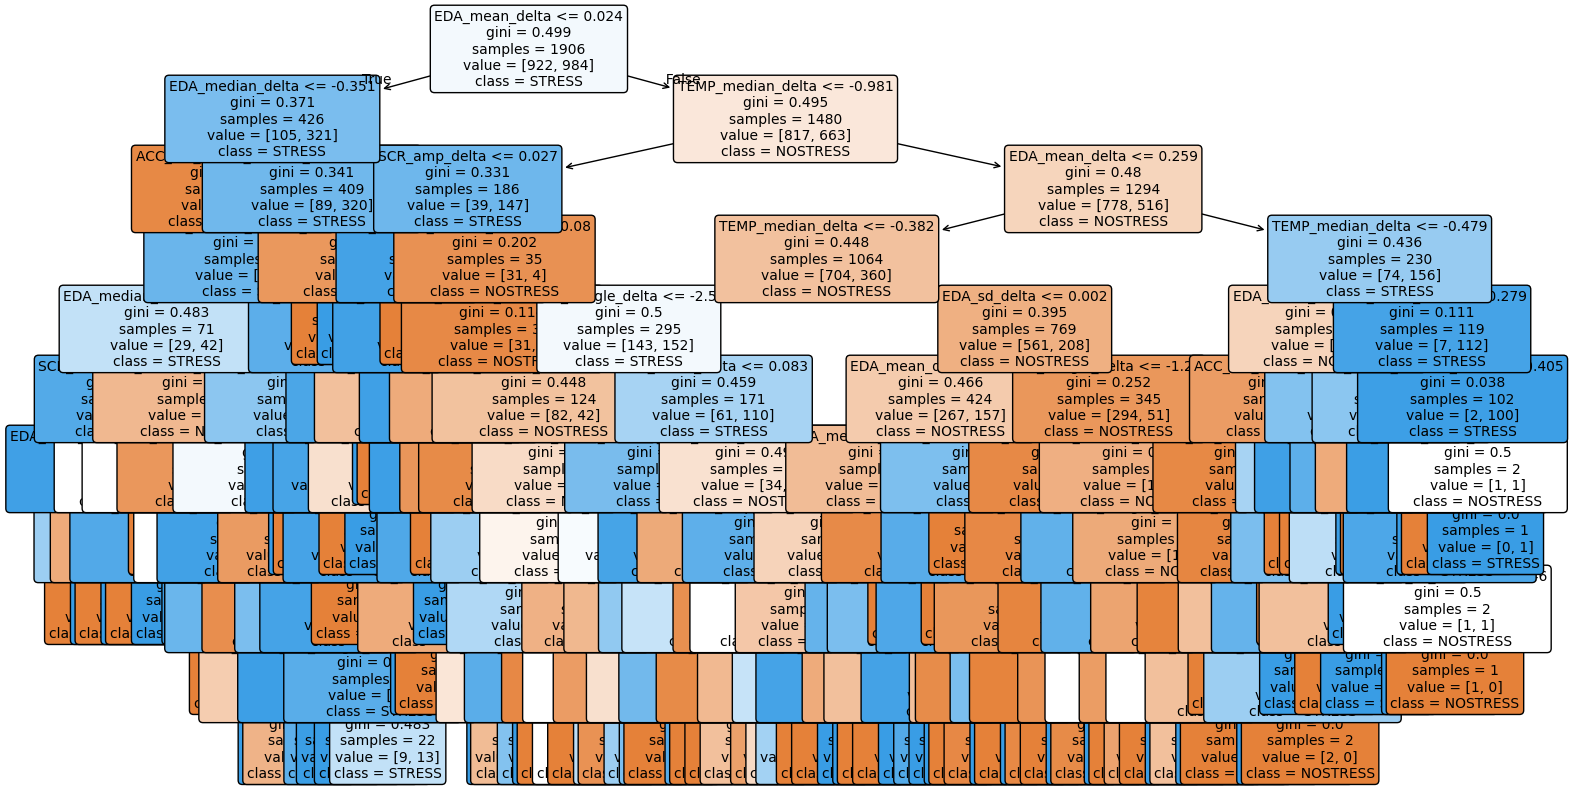

In [58]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# --- Train classifier ---
fruad_cls = DecisionTreeClassifier(
    random_state=1234,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1
)

fruad_cls.fit(X_reduced, y)  # y should contain class labels

# --- Visualize tree ---
plt.figure(figsize=(18, 10))
plot_tree(fruad_cls,
          feature_names=X_reduced.columns,
          class_names=[str(c) for c in fruad_cls.classes_],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()


## GRIDSEARCH

In [59]:
%%time

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeClassifier

# --- Define parameter grid ---
param_grid = {
    'max_depth': list(range(2, 21)),
    'min_samples_split': list(range(2, 21)),
    'min_samples_leaf': list(range(1, 11))
}

# --- Cross-validation setup ---
cv = KFold(n_splits=10, shuffle=True, random_state=1234)

# --- Initialize classifier ---
dt_cls = DecisionTreeClassifier(random_state=1234)

# --- Grid search with CV ---
grid_search_cls = GridSearchCV(
    estimator=dt_cls,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy'  # or 'roc_auc' for binary classification
)

grid_search_cls.fit(X_reduced, y)

# --- Best estimator and score ---
print("Best Classifier Params:", grid_search_cls.best_params_)
print("Best CV Score:", grid_search_cls.best_score_)


Best Classifier Params: {'max_depth': 13, 'min_samples_leaf': 6, 'min_samples_split': 2}
Best CV Score: 0.8142243042160375
CPU times: user 5min 5s, sys: 311 ms, total: 5min 5s
Wall time: 44min 40s


## Optuna 

In [60]:
%%time

import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import accuracy_score

# --- Define the Optuna objective function ---
def objective(trial):
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    dt_cls = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=1234
    )

    # Use cross-validated accuracy as the objective metric
    cv = KFold(n_splits=10, shuffle=True, random_state=1234)
    score = cross_val_score(dt_cls, X_reduced, y, cv=cv, scoring="accuracy")
    return score.mean()  # Optuna will maximize this automatically

# --- Run Optuna study ---
sampler = optuna.samplers.TPESampler(seed=1234)
study = optuna.create_study(direction="maximize", sampler=sampler)

study.optimize(objective, n_trials=50)

# --- Results ---
print("Best Parameters:", study.best_params)
print("Best CV Accuracy:", study.best_value)


[I 2026-01-26 12:55:40,629] A new study created in memory with name: no-name-cf06c3f9-61de-4bb0-8396-9d8489d4b70c
[I 2026-01-26 12:55:41,294] Trial 0 finished with value: 0.7492229264260125 and parameters: {'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.7492229264260125.
[I 2026-01-26 12:55:42,495] Trial 1 finished with value: 0.7985174979333151 and parameters: {'max_depth': 16, 'min_samples_split': 16, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.7985174979333151.
[I 2026-01-26 12:55:42,941] Trial 2 finished with value: 0.7764783686966107 and parameters: {'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.7985174979333151.
[I 2026-01-26 12:55:43,810] Trial 3 finished with value: 0.8068751722237533 and parameters: {'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 6}. Best is trial 3 with value: 0.8068751722237533.
[I 2026-01-26 12:55:45,655] Trial 4 finished with value: 0.8

Best Parameters: {'max_depth': 13, 'min_samples_split': 15, 'min_samples_leaf': 6}
Best CV Accuracy: 0.8121355745384402
CPU times: user 4.83 s, sys: 25.3 ms, total: 4.85 s
Wall time: 54.7 s


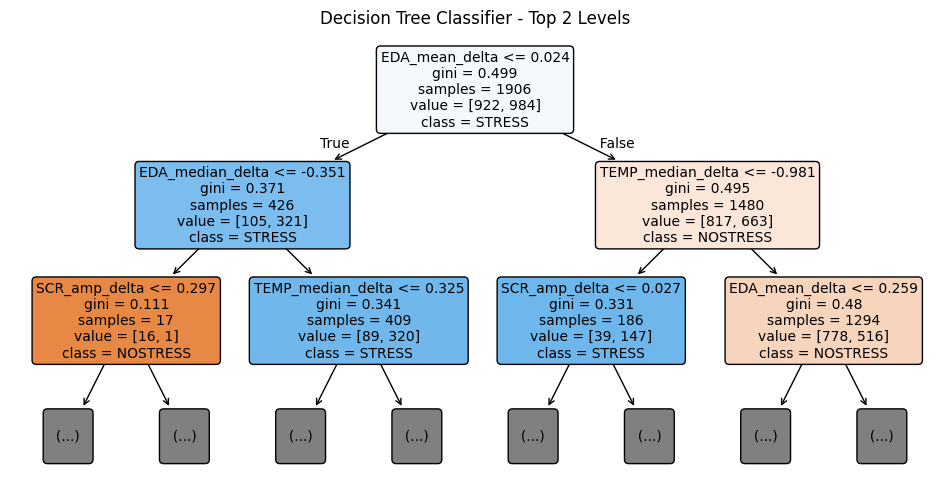

In [61]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# --- Train classifier ---
fraud_cls2 = DecisionTreeClassifier(
    random_state=1234,
    max_depth=13,
    min_samples_split=15,
    min_samples_leaf=6
)

fraud_cls2.fit(X_reduced, y)  # y should contain class labels

# --- Visualize tree (show top 2 levels) ---
plt.figure(figsize=(12, 6))
plot_tree(
    fraud_cls2,  # Use the trained classifier
    feature_names=X_reduced.columns,
    class_names=[str(c) for c in fraud_cls2.classes_],  # also from the trained classifier
    filled=True,
    rounded=True,
    max_depth=2,
    fontsize=10
)
plt.title("Decision Tree Classifier - Top 2 Levels")
plt.show()


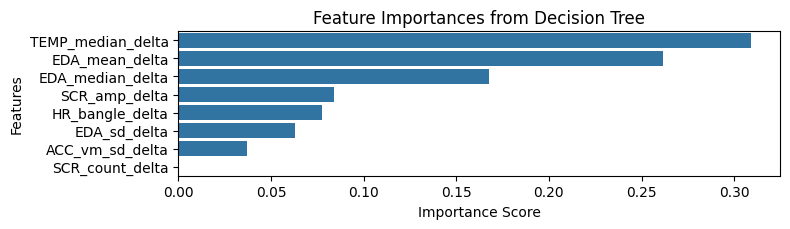

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from trained tree
importances = fraud_cls2.feature_importances_

# Create a Series with feature names from X_reduced
feature_importances = pd.Series(importances, index=X_reduced.columns)
sorted_importances = feature_importances.sort_values(ascending=False)

# Plot
plt.figure(figsize=(8, len(sorted_importances) * 0.3))  # dynamic height
sns.barplot(x=sorted_importances.values, y=sorted_importances.index)
plt.title("Feature Importances from Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [63]:
# --- Predict probabilities for the training set ---
train_o['pred_prob'] = fraud_cls2.predict_proba(X_reduced)[:, 1]  # probability of class 1 (Stress)

# Optional: preview
train_o[['pred_prob']].head()

,pred_prob
2220,0.000000
850,0.111111
427,0.000000
1162,0.000000
849,0.111111


In [64]:
from sklearn.metrics import roc_auc_score

# --- Ensure we have predicted probabilities ---
# Already stored in train_o['pred_prob']
train_o['p_hat'] = train_o['pred_prob']  # probability of Stress = 1

# --- Compute ROC-AUC (C-statistic) ---
auc = roc_auc_score(train_o['Label'], train_o['p_hat'])
print("C-statistic (AUC):", auc)

# --- Compute Somer's D ---
somer_d = 2 * auc - 1
print("Somer's D:", somer_d)


C-statistic (AUC): 0.9712498677318662
Somer's D: 0.9424997354637323


In [65]:
from sklearn.metrics import roc_curve
import pandas as pd

# --- Ensure proper data types ---
y = train_o['Label'].map({'NOSTRESS': 0, 'STRESS': 1})


y_true = y.astype(int)

y_score = train_o['p_hat'].astype(float)

# --- Check for both classes ---
if len(set(y_true)) < 2:
    raise ValueError("y_true has only one class. Need both positive and negative samples.")

# --- Compute ROC curve ---
fpr, tpr, thresholds = roc_curve(y_true, y_score)

# --- Compute Youden's J statistic ---
youden = pd.DataFrame({
    'TPR': tpr,
    'FPR': fpr,
    'Cut-off': thresholds,
    'Youden': tpr - fpr
})

# --- Sort by Youden's J ---
youden = youden.sort_values(by='Youden', ascending=False).reset_index(drop=True)

# --- Best cutoff ---
best_threshold = youden.loc[0, 'Cut-off']
print("Best threshold (Youden's J):", best_threshold)

# Optional: show top 5 thresholds
youden.head()


Best threshold (Youden's J): 0.5454545454545454


,TPR,FPR,Cut-off,Youden
0,0.880081,0.082430,0.545455,0.797652
1,0.873984,0.077007,0.583333,0.796977
2,0.915650,0.120390,0.500000,0.795260
3,0.859756,0.066161,0.625000,0.793596
4,0.927846,0.137744,0.428571,0.790101


In [66]:
import pandas as pd

# --- Convert predicted probabilities to class labels ---
# Use 0.5 cutoff; you can also replace 0.5 with best_threshold if desired
train_o['pred'] = train_o['pred_prob'].map(lambda x: 1 if x >0.5454545454545454 else 0)

# --- Create confusion matrix ---
conf_matrix = pd.crosstab(train_o['Label'], train_o['pred'],
                          rownames=['Actual'], colnames=['Predicted'])

print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 Predicted    0    1
Actual             
NOSTRESS   851   71
STRESS     124  860


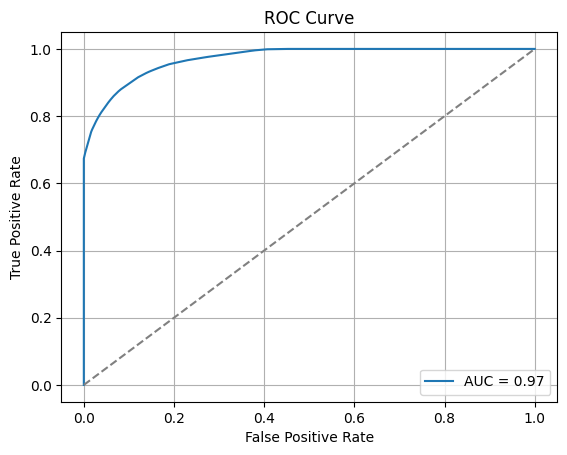

In [67]:
# Roc Curve
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

auc = roc_auc_score(y, train_o['pred_prob'])

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # chance line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

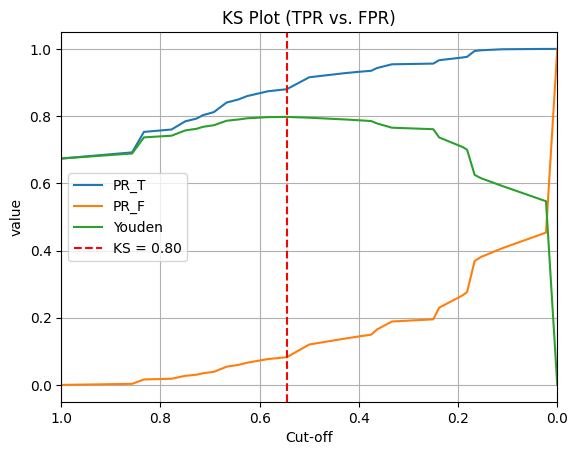

In [68]:
# KS plot 
import seaborn as sns

fpr, tpr, thresholds = roc_curve(y, train_o['pred_prob'])

# Create the Youden DataFrame
youden = pd.DataFrame({
    'Cut-off': thresholds,
    'TPR': tpr,
    'FPR': fpr,
    'Youden': tpr - fpr
})

# Sort by Cut-off and rename
youden = youden.sort_values(by='Cut-off', ascending=True)

ks_stat = youden.rename(columns={'TPR': 'PR_T', 'FPR': 'PR_F'})
ks_stat = ks_stat.melt(id_vars='Cut-off', var_name='PR', value_name='value')

ks_val = (youden['TPR'] - youden['FPR']).max()
ks_cutoff = youden.loc[(youden['TPR'] - youden['FPR']).idxmax(), 'Cut-off']

# Plot
sns.lineplot(x='Cut-off', y='value', hue='PR', data=ks_stat)
plt.xlim(1, 0)
plt.title("KS Plot (TPR vs. FPR)")
plt.grid(True)
plt.axvline(x=ks_cutoff, linestyle='--', color='red', label=f'KS = {ks_val:.2f}')
plt.legend()
plt.show()


In [69]:
# Precision, Recall, Cut-off, F1
train_o['Label'] = y
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

precision = np.array([])
recall = np.array([])
f1score = np.array([])

for y in range(100):
  train_o['pred'] = train_o['pred_prob'].map(lambda x: 1 if x > y/100 else 0)
  value_p = precision_score(train_o['Label'], train_o['pred'])
  precision = np.append(precision, value_p)
  value_r = recall_score(train_o['Label'], train_o['pred'])
  recall = np.append(recall, value_r)
  value_f = f1_score(train_o['Label'], train_o['pred'])
  f1score = np.append(f1score, value_f)

data = {'Precision': precision, 'Recall': recall, 'Cut-off': range(100), 'F1': f1score}
f1_s = pd.DataFrame(data)

f1_s.sort_values(by = ['F1'], ascending = False)

,Precision,Recall,Cut-off,F1
48,0.890316,0.915650,48,0.902806
43,0.890316,0.915650,43,0.902806
44,0.890316,0.915650,44,0.902806
46,0.890316,0.915650,46,0.902806
47,0.890316,0.915650,47,0.902806
49,0.890316,0.915650,49,0.902806
45,0.890316,0.915650,45,0.902806
41,0.877885,0.927846,41,0.902174
40,0.877885,0.927846,40,0.902174
42,0.877885,0.927846,42,0.902174


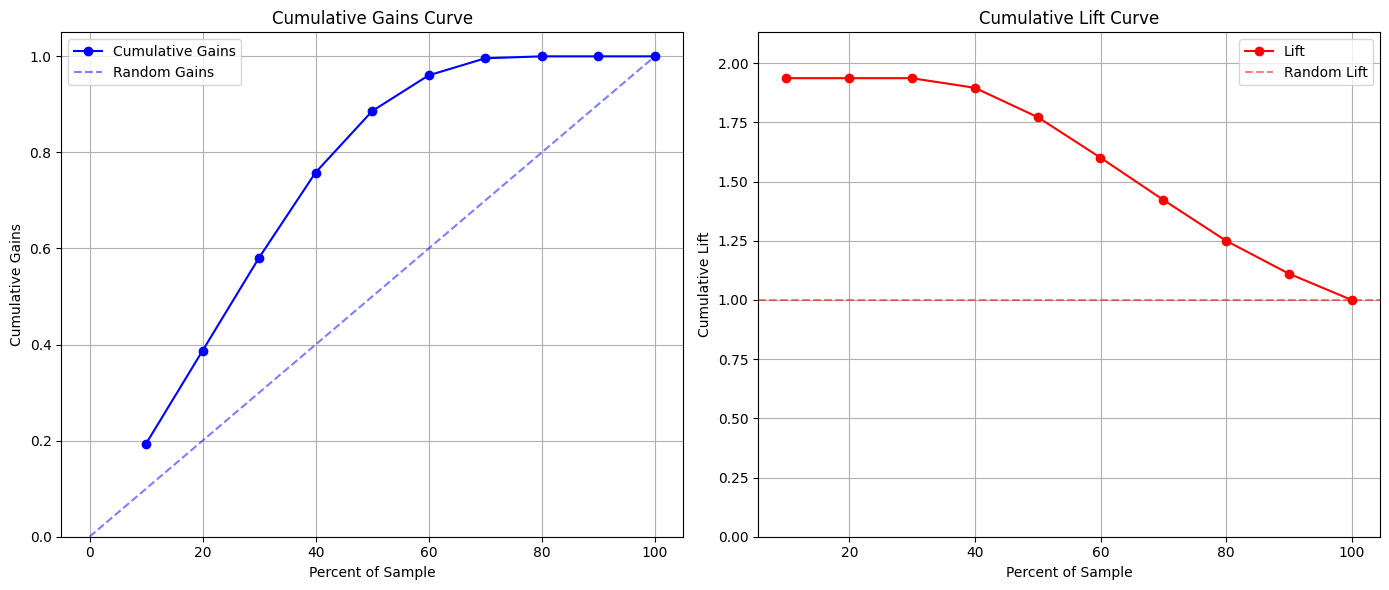

In [70]:
# Gains and lift Graph
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_lift_and_gains(y_true, y_proba, n_bins=10):
    """
    Plot Lift and Cumulative Gains curves.
    
    Parameters:
    - y_true: array-like, true binary labels (0/1)
    - y_proba: array-like, predicted probabilities for the positive class
    - n_bins: number of bins/deciles to split data
    
    Returns:
    - None (plots the curves)
    """
    df = pd.DataFrame({
        'y_true': y_true,
        'y_proba': y_proba
    })
    
    # Sort descending by predicted probability
    df = df.sort_values(by='y_proba', ascending=False).reset_index(drop=True)
    
    # Add cumulative counts
    df['cum_total'] = np.arange(1, len(df) + 1)
    df['cum_positives'] = df['y_true'].cumsum()
    
    total_positives = df['y_true'].sum()
    total_samples = len(df)
    
    # Cumulative Gains: % positives captured vs % samples
    df['cum_gains'] = df['cum_positives'] / total_positives
    
    # Lift: (cumulative gains) / (cumulative % of sample)
    df['cum_lift'] = df['cum_gains'] / (df['cum_total'] / total_samples)
    
    # Sample points for plotting (deciles)
    cutoffs = np.linspace(0, total_samples, n_bins + 1, dtype=int)
    cutoffs = cutoffs[cutoffs > 0]  # remove zero
    plot_points = df.loc[cutoffs - 1, ['cum_total', 'cum_gains', 'cum_lift']].copy()
    plot_points['percent_samples'] = plot_points['cum_total'] / total_samples * 100
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot Cumulative Gains
    axes[0].plot(plot_points['percent_samples'], plot_points['cum_gains'], marker='o', color='blue', label='Cumulative Gains')
    axes[0].plot([0, 100], [0, 1], linestyle='--', color='blue', alpha=0.5, label='Random Gains')
    axes[0].set_xlabel('Percent of Sample')
    axes[0].set_ylabel('Cumulative Gains')
    axes[0].set_title('Cumulative Gains Curve')
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(True)
    axes[0].legend()
    
    # Plot Lift
    axes[1].plot(plot_points['percent_samples'], plot_points['cum_lift'], marker='o', color='red', label='Lift')
    axes[1].axhline(1, linestyle='--', color='red', alpha=0.5, label='Random Lift')
    axes[1].set_xlabel('Percent of Sample')
    axes[1].set_ylabel('Cumulative Lift')
    axes[1].set_title('Cumulative Lift Curve')
    axes[1].set_ylim(0, plot_points['cum_lift'].max() * 1.1)
    axes[1].grid(True)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Example:
plot_lift_and_gains(train_o['Label'], train_o['pred_prob'])


## TEST

### Transforming the test 

In [71]:
test_o= test.copy()
num_cols_test = test_o.select_dtypes(include='number').columns

for col in num_cols_test:
    if test_o[col].isnull().any():
        # Create missing flag column
        test_o[f'{col}_was_missing'] = test_o[col].isnull().astype(int)

        # Impute with median
        median = test_o[col].median()
        test_o[col] = test_o[col].fillna(median)
print(test_o.columns)

Index(['Label', 'EDA_mean_delta', 'EDA_median_delta', 'EDA_sd_delta',
       'SCR_count_delta', 'SCR_amp_delta', 'HR_median_delta',
       'TEMP_median_delta', 'ACC_vm_mean_delta', 'ACC_vm_sd_delta',
       'HR_bangle_delta', 'HR_conf_delta', 'RMSSD_ECG_delta'],
      dtype='object')


In [72]:
# Prepare test predictors
predictors_test = test_o.drop(columns=['Label'])
predictors_test = pd.get_dummies(predictors_test, drop_first=True)
predictors_test = predictors_test.astype(float)

# Align columns with training set
train_columns = X_reduced.columns  

# Add missing columns
for col in train_columns:
    if col not in predictors_test.columns:
        predictors_test[col] = 0

# Keep only training columns and order them
predictors_test = predictors_test[train_columns]

# Final X_test
X_test = predictors_test

# Correct y_test (from test_o, not train_o)
y_test = test_o['Label'].map({'NOSTRESS': 0, 'STRESS': 1})


In [73]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, recall_score,
    precision_score, f1_score, confusion_matrix, classification_report
)
import pandas as pd

def evaluate_classification(model, X, y, model_name, threshold):
    """
    Compute classification metrics for a given model and threshold.
    
    Parameters:
    - model: fitted model with predict_proba
    - X: features
    - y: true binary labels
    - model_name: string label for output
    - threshold: probability cutoff for binary prediction
    """
    # Predicted probabilities for positive class
    y_prob = model.predict_proba(X)[:, 1]
    
    # Convert probabilities to binary predictions using threshold
    y_pred = (y_prob >= threshold).astype(int)
    
    # Compute metrics
    accuracy = accuracy_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)
    recall = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    # Confusion matrix and classification report
    cm = confusion_matrix(y, y_pred)
    report = classification_report(y, y_pred, digits=4)
    
    # Display results
    print(f"\n====== {model_name} CLASSIFICATION PERFORMANCE ======")
    print(f"Threshold: {threshold:.6f}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    
    print("\nConfusion Matrix:")
    print(cm)
    
    print("\nClassification Report:")
    print(report)
    
    # Return metrics as dictionary for further analysis
    metrics_dict = {
        'Model': model_name,
        'Threshold': threshold,
        'Accuracy': accuracy,
        'ROC-AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ConfusionMatrix': cm,
        'ClassificationReport': report
    }
    
    return metrics_dict


In [74]:
metrics_Decision = evaluate_classification(fraud_cls2, X_test, y_test, "Decision Tree", threshold=0.5454545454545454)



====== Decision Tree CLASSIFICATION PERFORMANCE ======
Threshold: 0.545455
Accuracy : 0.7717
ROC-AUC  : 0.8624
Precision: 0.8123
Recall   : 0.7256
F1 Score : 0.7665

Confusion Matrix:
[[252  55]
 [ 90 238]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7368    0.8208    0.7766       307
           1     0.8123    0.7256    0.7665       328

    accuracy                         0.7717       635
   macro avg     0.7746    0.7732    0.7715       635
weighted avg     0.7758    0.7717    0.7714       635

